# Predicting Core PCE and Core CPI Using FSBI and Macroeconomic Variables
**ISYE/CSE/MGT 6748 Applied Analytics Practicum — Georgia Institute of Technology**  
**Sponsor: Fiserv | Team 2: Eric Qiu · Kai Pang · Kwangmyung Lee**

---
## Notebook Structure
- **Part 1 (Cells 1–2):** Data collection — FSBI, FRED macro variables
- **Part 2 (Cells 3–4):** Data merging, feature engineering, CV helpers
- **Part 3 (Cell 5):** Main loop — runs all models for Core PCE and Core CPI
- **Part 4 (Cells 6–8):** Combined results, visualization, prediction table for Lee

---
## Part 1: Data Collection

In [1]:
# ── Imports ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fredapi import Fred
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from matplotlib.patches import Patch

FRED_API_KEY = '549d8602d24a67c414ae95371fbcc4e8'
fred = Fred(api_key=FRED_API_KEY)

# ── Targets to run ─────────────────────────────────────────────
# Both Core PCE and Core CPI are run in the main loop (Cell 5).
# Core PCE: Fed's preferred inflation measure
# Core CPI: Most market-watched, released ~2 weeks earlier than Core PCE
TARGETS = ['Core_PCE', 'Core_CPI']

print('Imports OK')
print(f'Targets: {TARGETS}')

Imports OK
Targets: ['Core_PCE', 'Core_CPI']


In [2]:
# ── Cell 1: Load FSBI data (national level) ────────────────────
# Geo=US, Sector=ALL, Sub-Sector=ALL for clean national-level comparison.
# YOY/MOM columns are dropped (not filled with zero) to avoid
# introducing false signals from the first 12 months of NaNs.

df_raw = pd.read_csv('FSBI_data.csv')
df_raw['date'] = pd.to_datetime(df_raw['Period'].astype(str), format='%Y%m%d')

df_national = (
    df_raw[
        (df_raw['Geo'] == 'US') &
        (df_raw['Sector Name'] == 'ALL') &
        (df_raw['Sub-Sector Name'] == 'ALL')
    ]
    [['date', 'Real Sales Index - SA', 'Transactional Index - SA',
      'Real Sales MOM % - SA', 'Transaction MOM % - SA',
      'Real Sales YOY % - SA', 'Transaction YOY %  - SA']]
    .copy()
    .reset_index(drop=True)
)

# Lag features: lag-1, lag-2, lag-3 (consistent with v6 best setup)
for lag in [1, 2, 3]:
    df_national[f'fsbi_real_lag{lag}']  = df_national['Real Sales Index - SA'].shift(lag)
    df_national[f'fsbi_trans_lag{lag}'] = df_national['Transactional Index - SA'].shift(lag)
    df_national[f'fsbi_yoy_lag{lag}']   = df_national['Real Sales YOY % - SA'].shift(lag)

print(f'FSBI national rows: {len(df_national)}')
print(f'Date range: {df_national["date"].min().date()} to {df_national["date"].max().date()}')
df_national.head(3)

FSBI national rows: 89
Date range: 2019-01-01 to 2026-05-01


,date,Real Sales Index - SA,Transactional Index - SA,Real Sales MOM % - SA,Transaction MOM % - SA,Real Sales YOY % - SA,Transaction YOY % - SA,fsbi_real_lag1,fsbi_trans_lag1,fsbi_yoy_lag1,fsbi_real_lag2,fsbi_trans_lag2,fsbi_yoy_lag2,fsbi_real_lag3,fsbi_trans_lag3,fsbi_yoy_lag3
0,2019-01-01,97.42,98.29,0.00,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,95.76,97.04,-1.71,-1.27,0.0,0.0,97.42,98.29,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,97.21,98.98,1.51,1.99,0.0,0.0,95.76,97.04,0.0,97.42,98.29,0.0,NaN,NaN,NaN


In [3]:
# ── Cell 2: Pull macro data from FRED ──────────────────────────

# Target series: all four inflation measures pulled here;
# the loop in Cell 5 selects the relevant one each time.
target_series = {
    'CPI':      'CPIAUCSL',
    'Core_CPI': 'CPILFESL',
    'PCE':      'PCEPI',
    'Core_PCE': 'PCEPILFE',
}
targets = pd.DataFrame({
    name: fred.get_series(ticker)
    for name, ticker in target_series.items()
})
targets.index = pd.to_datetime(targets.index)
targets = targets.loc['2019-01-01':].resample('MS').last()
for col in ['CPI', 'Core_CPI', 'PCE', 'Core_PCE']:
    targets[f'{col}_YOY'] = targets[col].pct_change(12) * 100
    targets[f'{col}_MOM'] = targets[col].pct_change(1)  * 100
targets.index.name = 'date'
targets = targets.reset_index()

# Monthly FRED macro variables
# Note: WPSFD4 and EIUIR are BLS series IDs, not available via fredapi.
# WPSFD4 is replaced by PPIFID; EIUIR is excluded.
monthly_series = {
    'housing_starts':            'HOUST',
    'housing_permits':           'PERMIT',
    'commodity_ppi':             'PPIACO',
    'm1':                        'M1SL',
    'm2':                        'M2SL',
    'inflation_expectations_1y': 'MICH',
    'fed_funds':                 'FEDFUNDS',
    'unemployment_rate':         'UNRATE',
    'avg_hourly_earnings':       'CES0500000003',
    'ppi_final_demand':          'PPIFID',
    'cpi_rent':                  'CUUR0000SEHA',
    'cpi_oer':                   'CUUR0000SEHC',
    'cpi_gasoline':              'CUUR0000SETB01',
}
fred_monthly = pd.DataFrame({
    name: fred.get_series(ticker)
    for name, ticker in monthly_series.items()
})
fred_monthly.index = pd.to_datetime(fred_monthly.index)
fred_monthly = fred_monthly.loc['2019-01-01':].resample('MS').last()
fred_monthly.index.name = 'date'
fred_monthly = fred_monthly.reset_index()

# Daily FRED → monthly (month-end value aligned to month-start)
daily_series = {
    'treasury_2y':   'DGS2',
    'treasury_10y':  'DGS10',
    'breakeven_5y':  'T5YIE',
    'breakeven_10y': 'T10YIE',
    'usd_index':     'DTWEXBGS',
}
fred_daily_raw = pd.DataFrame({
    name: fred.get_series(ticker)
    for name, ticker in daily_series.items()
})
fred_daily_raw.index = pd.to_datetime(fred_daily_raw.index)
fred_daily = fred_daily_raw.loc['2019-01-01':].resample('M').last()
fred_daily.index = fred_daily.index.to_period('M').to_timestamp()
fred_daily['yield_spread_10y2y'] = fred_daily['treasury_10y'] - fred_daily['treasury_2y']
fred_daily.index.name = 'date'
fred_daily = fred_daily.reset_index()

# Weekly FRED → monthly
weekly_series = {
    'nfci':    'NFCI',
    'stl_fsi': 'STLFSI4',
}
fred_weekly_raw = pd.DataFrame({
    name: fred.get_series(ticker)
    for name, ticker in weekly_series.items()
})
fred_weekly_raw.index = pd.to_datetime(fred_weekly_raw.index)
fred_weekly = fred_weekly_raw.loc['2019-01-01':].resample('M').last()
fred_weekly.index = fred_weekly.index.to_period('M').to_timestamp()
fred_weekly.index.name = 'date'
fred_weekly = fred_weekly.reset_index()

print('Targets shape:       ', targets.shape)
print('Monthly FRED shape:  ', fred_monthly.shape)
print('Daily→Monthly shape: ', fred_daily.shape)
print('Weekly→Monthly shape:', fred_weekly.shape)

Targets shape:        (89, 13)
Monthly FRED shape:   (90, 14)
Daily→Monthly shape:  (91, 7)
Weekly→Monthly shape: (90, 3)


In [4]:
# Quick data completeness check after re-pulling
print('=== Missing values check (2021 onwards) ===')
check_df = fred_monthly[fred_monthly['date'] >= '2021-01-01']
missing = check_df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('✓ No missing values in fred_monthly')
else:
    print('Missing values found:')
    print(missing)
    print('\nAffected dates:')
    for col in missing.index:
        bad_dates = check_df[check_df[col].isnull()]['date'].tolist()
        print(f'  {col}: {bad_dates}')

=== Missing values check (2021 onwards) ===
Missing values found:
housing_starts               1
housing_permits              1
commodity_ppi                1
m1                           1
m2                           1
inflation_expectations_1y    1
unemployment_rate            1
ppi_final_demand             1
cpi_rent                     2
cpi_oer                      2
cpi_gasoline                 1
dtype: int64

Affected dates:
  housing_starts: [Timestamp('2026-06-01 00:00:00')]
  housing_permits: [Timestamp('2026-06-01 00:00:00')]
  commodity_ppi: [Timestamp('2026-06-01 00:00:00')]
  m1: [Timestamp('2026-06-01 00:00:00')]
  m2: [Timestamp('2026-06-01 00:00:00')]
  inflation_expectations_1y: [Timestamp('2026-06-01 00:00:00')]
  unemployment_rate: [Timestamp('2025-10-01 00:00:00')]
  ppi_final_demand: [Timestamp('2026-06-01 00:00:00')]
  cpi_rent: [Timestamp('2025-10-01 00:00:00'), Timestamp('2026-06-01 00:00:00')]
  cpi_oer: [Timestamp('2025-10-01 00:00:00'), Timestamp('2026-06-0

---
## Part 2: Data Merging, Feature Engineering, and CV Setup

In [5]:
# ── Cell 3: Merge all sources and build base model_df ──────────
# This merged dataframe contains all features and all four target
# series. The loop in Cell 5 selects the relevant target columns.

model_df_base = (
    df_national
    .merge(targets,      on='date', how='inner')
    .merge(fred_monthly, on='date', how='left')
    .merge(fred_daily,   on='date', how='left')
    .merge(fred_weekly,  on='date', how='left')
    .sort_values('date')
    .reset_index(drop=True)
)

# Lag macro variables by 1 month to prevent look-ahead bias
macro_lag_cols = [
    'fed_funds', 'unemployment_rate', 'avg_hourly_earnings',
    'ppi_final_demand', 'cpi_rent', 'cpi_oer',
    'inflation_expectations_1y', 'treasury_10y',
    'breakeven_5y', 'yield_spread_10y2y', 'usd_index'
]
for col in macro_lag_cols:
    if col in model_df_base.columns:
        model_df_base[f'{col}_lag1'] = model_df_base[col].shift(1)



# Filter to 2021+ (post-COVID inflationary period)
model_df_base = model_df_base[
    model_df_base['date'] >= '2021-01-01'
].reset_index(drop=True)

print(f'Base dataset: {len(model_df_base)} months')
print(f'Date range: {model_df_base["date"].min().date()} to {model_df_base["date"].max().date()}')

Base dataset: 65 months
Date range: 2021-01-01 to 2026-05-01


In [6]:
# ── Cell 4: Feature sets and CV helper functions ───────────────

# Fixed feature sets (same for both targets)
MACRO_FEATURES = [
    'fed_funds_lag1',
    'treasury_10y_lag1',
    'yield_spread_10y2y_lag1',
    'breakeven_5y_lag1',
    'unemployment_rate_lag1',
    'avg_hourly_earnings_lag1',
    'ppi_final_demand_lag1',
    'cpi_rent_lag1',
    'cpi_oer_lag1',
    'inflation_expectations_1y_lag1',
    'usd_index_lag1',
]

FSBI_FEATURES = [
    'Real Sales Index - SA',
    'Transactional Index - SA',
    'Real Sales YOY % - SA',
    'fsbi_real_lag1', 'fsbi_trans_lag1', 'fsbi_yoy_lag1',
    'fsbi_real_lag2', 'fsbi_trans_lag2', 'fsbi_yoy_lag2',
    'fsbi_real_lag3', 'fsbi_trans_lag3', 'fsbi_yoy_lag3',
]

# Classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=3,
                                                   min_samples_leaf=3, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=42, verbosity=0),
}

# Regressors
regressors = {
    'Lasso':         Lasso(alpha=0.1, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=3,
                                            min_samples_leaf=3, random_state=42),
    'XGBoost':       XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbosity=0),
}

tscv = TimeSeriesSplit(n_splits=4)

def run_cv_cls(clf, X, y, scale=False):
    """Time-series CV for classification. Returns mean accuracy."""
    acc_list, y_true_all, y_pred_all = [], [], []
    scaler = StandardScaler()
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        if len(y_tr.unique()) < 2:
            continue
        if scale:
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc_list.append(accuracy_score(y_te, y_pred))
        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(y_pred.tolist())
    return np.mean(acc_list), y_true_all, y_pred_all


def run_cv_reg(reg, X, y, scale=True, min_train=20):
    """Time-series CV for regression. Returns mean MAE, RMSE, R².
    
    Folds with fewer than min_train samples are skipped to avoid
    unstable estimates when features outnumber training observations.
    """
    mae_list, rmse_list, r2_list = [], [], []
    scaler = StandardScaler()
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        if len(train_idx) < min_train:
            continue
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]
        if scale:
            X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
            X_te = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns)
        reg.fit(X_tr, y_tr)
        y_pred = reg.predict(X_te)
        mae_list.append(mean_absolute_error(y_te, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_te, y_pred)))
        r2_list.append(r2_score(y_te, y_pred))
    if not mae_list:
        return np.nan, np.nan, np.nan
    return np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list)


print('Feature sets and CV helpers ready ✓')
print(f'Macro features: {len(MACRO_FEATURES)}')
print(f'FSBI features:  {len(FSBI_FEATURES)}')

Feature sets and CV helpers ready ✓
Macro features: 11
FSBI features:  12


---
## Part 3: Main Loop — Run All Models for Both Targets

This single cell runs the complete M0/M1/M2/M3 comparison for **both Core PCE and Core CPI**.  
All results are stored in `all_results` for combined reporting in Part 4.

In [7]:
# ── Cell 5: Main modeling loop ─────────────────────────────────
# Iterates over TARGETS = ['Core_PCE', 'Core_CPI'].
# For each target:
#   1. Build target-specific columns (direction, next_val, AR lags)
#   2. Define 4 model variants (M0/M1/M2/M3)
#   3. Run classification and regression CV
#   4. Store results in all_results dict

all_results = {}  # all_results[target] = {cls_results, reg_results, model_df, variants, baseline}

for TARGET in TARGETS:
    print('\n' + '='*65)
    print(f'TARGET: {TARGET}')
    print('='*65)

    # ── Build target-specific model_df ────────────────────────
    mdf = model_df_base.copy()

    # AR lag features for this target
    for lag in [1, 2, 3]:
        mdf[f'{TARGET}_YOY_lag{lag}'] = mdf[f'{TARGET}_YOY'].shift(lag)

    # Classification target: direction (rising=1, falling=0)
    mdf[f'{TARGET}_next_YOY']  = mdf[f'{TARGET}_YOY'].shift(-1)
    mdf[f'{TARGET}_direction'] = (
        mdf[f'{TARGET}_next_YOY'] > mdf[f'{TARGET}_YOY']
    ).astype(int)

    # Regression target: actual next-month YOY value
    mdf[f'{TARGET}_next_val'] = mdf[f'{TARGET}_YOY'].shift(-1)

    # AR features specific to this target
    AR_FEATURES = [
        f'{TARGET}_YOY_lag1',
        f'{TARGET}_YOY_lag2',
        f'{TARGET}_YOY_lag3',
    ]

    # Model variants
    variants = {
        'M0: AR Baseline':   AR_FEATURES,
        'M1: Macro Only':    AR_FEATURES + MACRO_FEATURES,
        'M2: FSBI Only':     AR_FEATURES + FSBI_FEATURES,
        'M3: Macro + FSBI':  AR_FEATURES + MACRO_FEATURES + FSBI_FEATURES,
    }

    # Drop NaN rows
    all_feats = AR_FEATURES + MACRO_FEATURES + FSBI_FEATURES
    mdf = mdf.dropna(
        subset=all_feats + [f'{TARGET}_direction', f'{TARGET}_next_val']
    ).reset_index(drop=True)

    y_cls = mdf[f'{TARGET}_direction']
    y_reg = mdf[f'{TARGET}_next_val']
    majority_acc = max(y_cls.mean(), 1 - y_cls.mean())

    print(f'Rows: {len(mdf)}  |  Baseline accuracy: {majority_acc:.1%}')
    print(f'Class balance — Rising: {y_cls.sum()}  Falling: {(1-y_cls).sum()}')

    # ── Classification CV ─────────────────────────────────────
    print(f'\nClassification CV...')
    cls_results = {}
    for variant_name, feat_cols in variants.items():
        X = mdf[feat_cols]
        variant_results = {}
        for clf_name, clf in classifiers.items():
            scale = 'Logistic' in clf_name
            acc, yt, yp = run_cv_cls(clf, X, y_cls, scale=scale)
            variant_results[clf_name] = acc
        cls_results[variant_name] = variant_results
        best = max(variant_results.values())
        print(f'  {variant_name:<22} best acc={best:.3f}')

    # ── Regression CV ─────────────────────────────────────────
    print(f'\nRegression CV...')
    reg_results = {}
    for variant_name, feat_cols in variants.items():
        X = mdf[feat_cols]
        variant_reg = {}
        for reg_name, reg in regressors.items():
            scale = 'Lasso' in reg_name
            mae, rmse, r2 = run_cv_reg(reg, X, y_reg, scale=scale, min_train=20)
            variant_reg[reg_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        reg_results[variant_name] = variant_reg
        best_mae = min(v['MAE'] for v in variant_reg.values())
        print(f'  {variant_name:<22} best MAE={best_mae:.4f}')

    # ── Store results ─────────────────────────────────────────
    all_results[TARGET] = {
        'cls_results':   cls_results,
        'reg_results':   reg_results,
        'model_df':      mdf,
        'variants':      variants,
        'AR_FEATURES':   AR_FEATURES,
        'majority_acc':  majority_acc,
        'y_cls':         y_cls,
        'y_reg':         y_reg,
    }

print('\n' + '='*65)
print('All targets complete ✓')


TARGET: Core_PCE
Rows: 60  |  Baseline accuracy: 50.0%
Class balance — Rising: 30  Falling: 30

Classification CV...
  M0: AR Baseline        best acc=0.479
  M1: Macro Only         best acc=0.562
  M2: FSBI Only          best acc=0.458
  M3: Macro + FSBI       best acc=0.542

Regression CV...
  M0: AR Baseline        best MAE=0.5138
  M1: Macro Only         best MAE=0.4103
  M2: FSBI Only          best MAE=0.3905
  M3: Macro + FSBI       best MAE=0.4192

TARGET: Core_CPI
Rows: 60  |  Baseline accuracy: 63.3%
Class balance — Rising: 22  Falling: 38

Classification CV...
  M0: AR Baseline        best acc=0.396
  M1: Macro Only         best acc=0.604
  M2: FSBI Only          best acc=0.458
  M3: Macro + FSBI       best acc=0.562

Regression CV...
  M0: AR Baseline        best MAE=0.7416
  M1: Macro Only         best MAE=0.5988
  M2: FSBI Only          best MAE=0.4832
  M3: Macro + FSBI       best MAE=0.6006

All targets complete ✓


---
## Part 4: Combined Results, Visualization, and Output

In [8]:
# ── Cell 6: Combined results summary table ─────────────────────

for TARGET in TARGETS:
    r = all_results[TARGET]
    cls_results  = r['cls_results']
    reg_results  = r['reg_results']
    variants     = r['variants']
    majority_acc = r['majority_acc']

    print(f'\n{"-"*65}')
    print(f'TARGET: {TARGET}')
    print(f'{"-"*65}')

    print('\nCLASSIFICATION (Accuracy)')
    header = f'{"":22}' + ''.join(f'{n:>20}' for n in classifiers)
    print(header)
    for variant_name in variants:
        row = f'{variant_name:<22}'
        for clf_name in classifiers:
            row += f'{cls_results[variant_name][clf_name]:>20.3f}'
        print(row)
    print(f'  Baseline: {majority_acc:.3f}')

    print('\nREGRESSION (MAE)')
    header = f'{"":22}' + ''.join(f'{n:>20}' for n in regressors)
    print(header)
    for variant_name in variants:
        row = f'{variant_name:<22}'
        for reg_name in regressors:
            row += f'{reg_results[variant_name][reg_name]["MAE"]:>20.4f}'
        print(row)

    print('\nFSBI VALUE-ADD (M3 vs M1)')
    for clf_name in classifiers:
        m1 = cls_results['M1: Macro Only'][clf_name]
        m3 = cls_results['M3: Macro + FSBI'][clf_name]
        arrow = '↑' if m3 > m1 else '↓'
        print(f'  {clf_name:<25} Acc: M1={m1:.3f} M3={m3:.3f} {arrow}{m3-m1:+.3f}')
    for reg_name in regressors:
        m1 = reg_results['M1: Macro Only'][reg_name]['MAE']
        m3 = reg_results['M3: Macro + FSBI'][reg_name]['MAE']
        arrow = '↓ better' if m3 < m1 else '↑ worse'
        print(f'  {reg_name:<25} MAE: M1={m1:.4f} M3={m3:.4f} {arrow} Δ={m3-m1:+.4f}')


-----------------------------------------------------------------
TARGET: Core_PCE
-----------------------------------------------------------------

CLASSIFICATION (Accuracy)
                       Logistic Regression       Random Forest             XGBoost
M0: AR Baseline                      0.479               0.333               0.354
M1: Macro Only                       0.562               0.354               0.292
M2: FSBI Only                        0.396               0.396               0.458
M3: Macro + FSBI                     0.542               0.500               0.417
  Baseline: 0.500

REGRESSION (MAE)
                                     Lasso       Random Forest             XGBoost
M0: AR Baseline                     0.5138              0.5250              0.6175
M1: Macro Only                      0.4787              0.5688              0.4103
M2: FSBI Only                       0.3905              0.4888              0.4235
M3: Macro + FSBI                    0.45

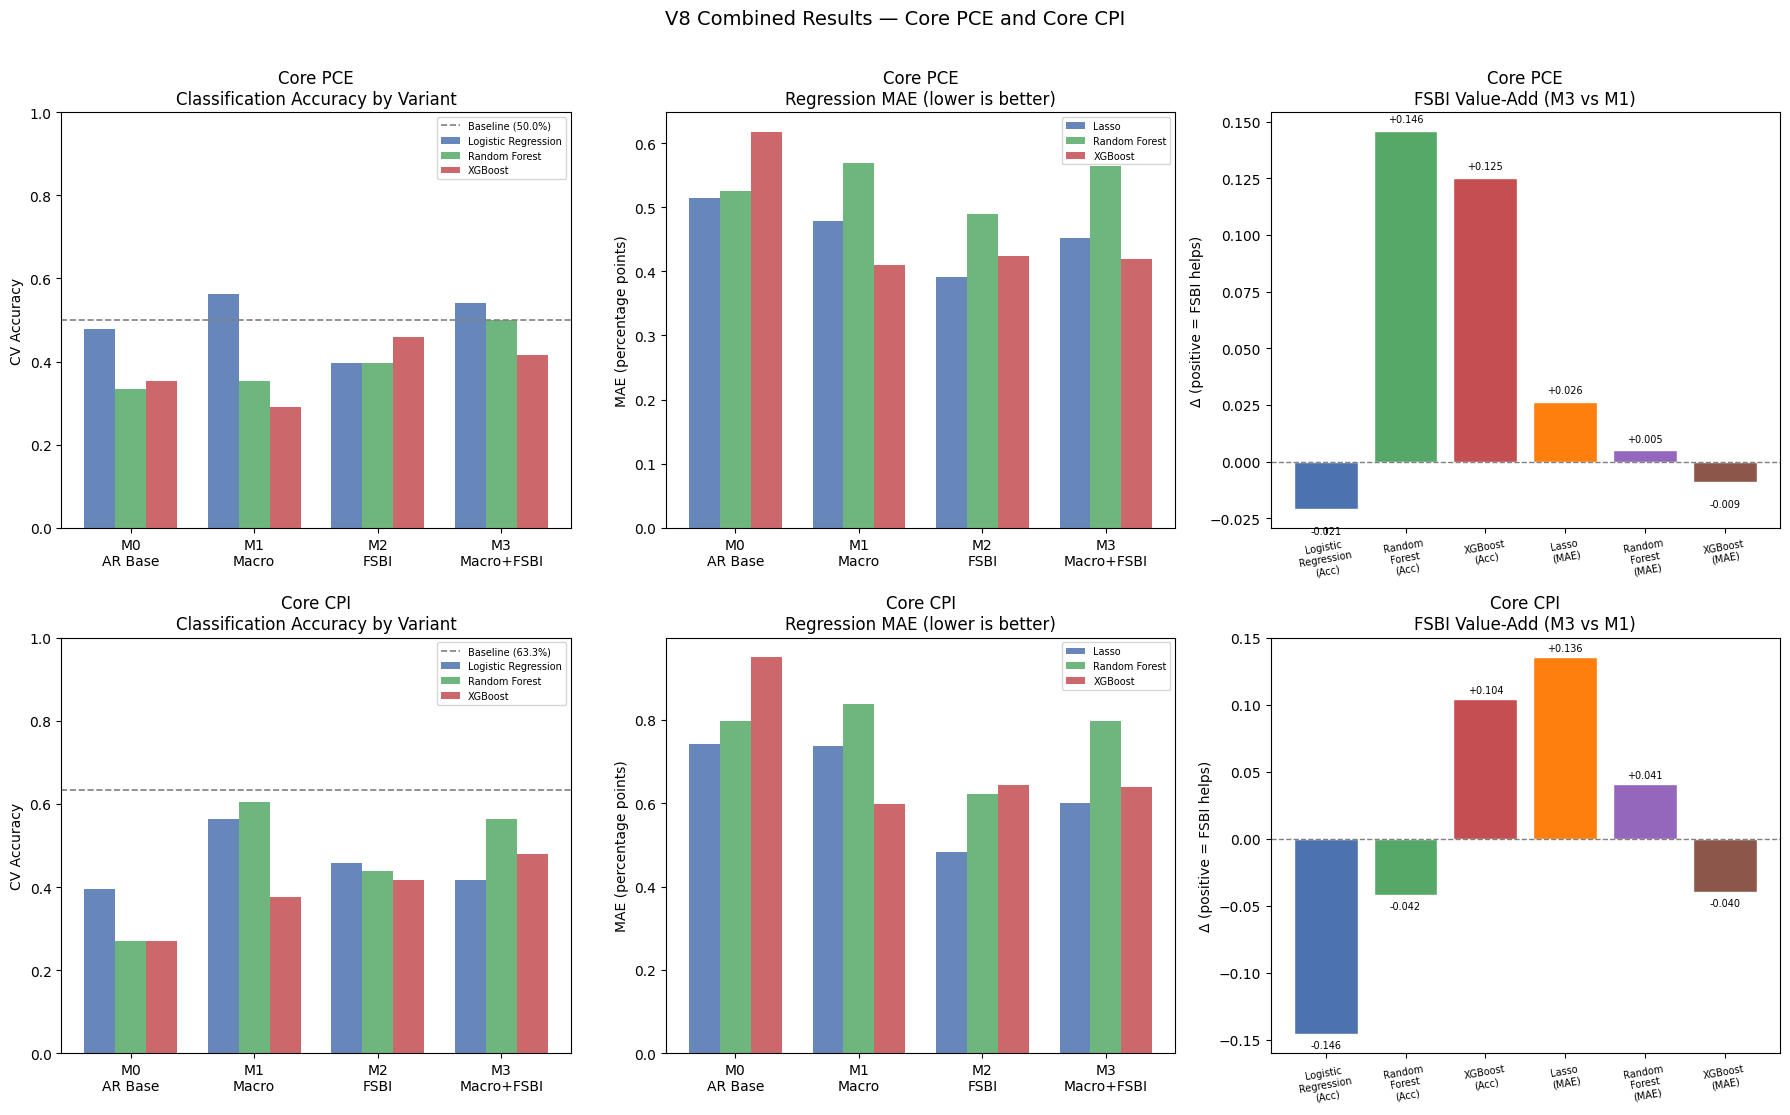

Saved: v8_combined_results.png


In [9]:
# ── Cell 7: Combined visualization ────────────────────────────
# Two rows (one per target), three columns (Acc / MAE / FSBI delta)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
variant_labels = ['M0\nAR Base', 'M1\nMacro', 'M2\nFSBI', 'M3\nMacro+FSBI']
clf_colors = ['#4C72B0', '#55a868', '#c44e52']
reg_colors = ['#4C72B0', '#55a868', '#c44e52']
extra_colors = ['#ff7f0e', '#9467bd', '#8c564b']

for row_idx, TARGET in enumerate(TARGETS):
    r            = all_results[TARGET]
    cls_results  = r['cls_results']
    reg_results  = r['reg_results']
    variants     = r['variants']
    majority_acc = r['majority_acc']

    label = 'Core PCE' if TARGET == 'Core_PCE' else 'Core CPI'
    x     = np.arange(len(variant_labels))
    width = 0.25

    # ── Left: classification accuracy ───────────────────────
    ax = axes[row_idx, 0]
    for i, (clf_name, color) in enumerate(zip(classifiers.keys(), clf_colors)):
        accs = [cls_results[v][clf_name] for v in variants]
        ax.bar(x + i*width, accs, width, label=clf_name, color=color, alpha=0.85)
    ax.axhline(majority_acc, color='gray', linestyle='--', linewidth=1.2,
               label=f'Baseline ({majority_acc:.1%})')
    ax.set_xticks(x + width)
    ax.set_xticklabels(variant_labels)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('CV Accuracy')
    ax.set_title(f'{label}\nClassification Accuracy by Variant')
    ax.legend(fontsize=7)

    # ── Middle: regression MAE ───────────────────────────────
    ax = axes[row_idx, 1]
    for i, (reg_name, color) in enumerate(zip(regressors.keys(), reg_colors)):
        maes = [reg_results[v][reg_name]['MAE'] for v in variants]
        ax.bar(x + i*width, maes, width, label=reg_name, color=color, alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(variant_labels)
    ax.set_ylabel('MAE (percentage points)')
    ax.set_title(f'{label}\nRegression MAE (lower is better)')
    ax.legend(fontsize=7)

    # ── Right: FSBI value-add delta ──────────────────────────
    ax = axes[row_idx, 2]
    labels_d, deltas_d, colors_d = [], [], []
    for clf_name, color in zip(classifiers.keys(), clf_colors):
        m1 = cls_results['M1: Macro Only'][clf_name]
        m3 = cls_results['M3: Macro + FSBI'][clf_name]
        labels_d.append(clf_name.replace(' ', '\n') + '\n(Acc)')
        deltas_d.append(m3 - m1)
        colors_d.append(color)
    for reg_name, color in zip(regressors.keys(), extra_colors):
        m1 = reg_results['M1: Macro Only'][reg_name]['MAE']
        m3 = reg_results['M3: Macro + FSBI'][reg_name]['MAE']
        labels_d.append(reg_name.replace(' ', '\n') + '\n(MAE)')
        deltas_d.append(-(m3 - m1))  # negate: lower MAE = positive
        colors_d.append(color)
    bars = ax.bar(labels_d, deltas_d, color=colors_d, edgecolor='white')
    for bar, val in zip(bars, deltas_d):
        ypos = val + 0.003 if val >= 0 else val - 0.012
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:+.3f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Δ (positive = FSBI helps)')
    ax.set_title(f'{label}\nFSBI Value-Add (M3 vs M1)')
    ax.tick_params(axis='x', rotation=10, labelsize=7)

plt.suptitle('V8 Combined Results — Core PCE and Core CPI', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('v8_combined_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v8_combined_results.png')

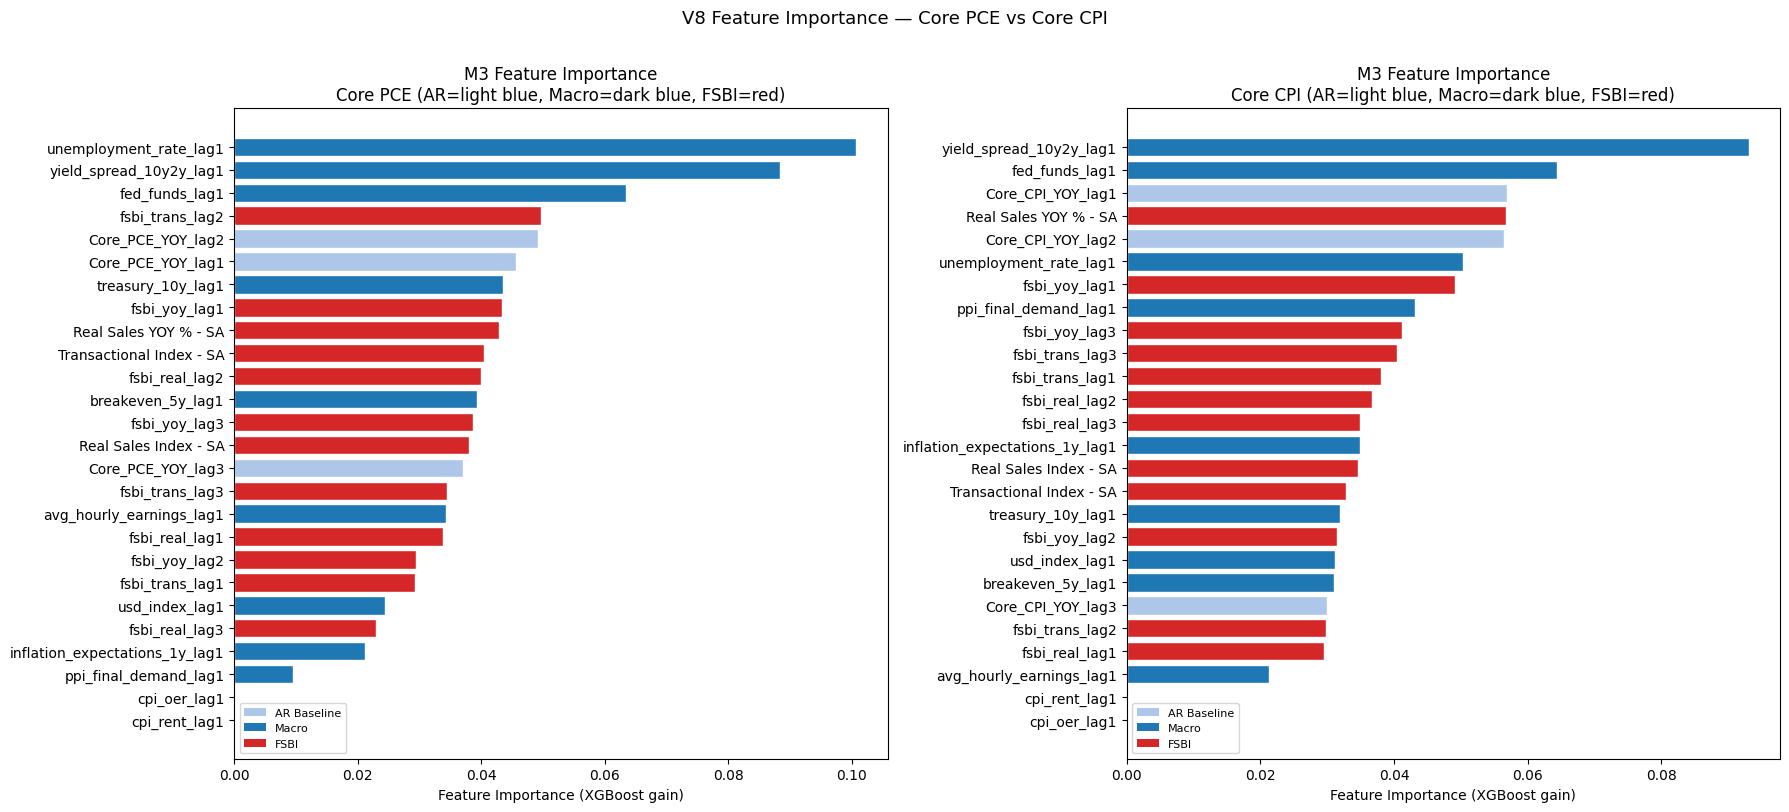

Saved: v8_feature_importance.png


In [10]:
# ── Cell 8: Feature importance for both targets (M3 XGBoost) ──

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for col_idx, TARGET in enumerate(TARGETS):
    r          = all_results[TARGET]
    mdf        = r['model_df']
    AR_FEATURES = r['AR_FEATURES']
    y_cls      = r['y_cls']
    label      = 'Core PCE' if TARGET == 'Core_PCE' else 'Core CPI'

    all_feats_m3 = AR_FEATURES + MACRO_FEATURES + FSBI_FEATURES
    xgb_m3 = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    )
    xgb_m3.fit(mdf[all_feats_m3], y_cls)

    importance_df = pd.DataFrame({
        'feature':    all_feats_m3,
        'importance': xgb_m3.feature_importances_,
        'type': (['AR']    * len(AR_FEATURES) +
                  ['Macro'] * len(MACRO_FEATURES) +
                  ['FSBI']  * len(FSBI_FEATURES))
    }).sort_values('importance', ascending=True)

    color_map  = {'AR': '#aec7e8', 'Macro': '#1f77b4', 'FSBI': '#d62728'}
    bar_colors = [color_map[t] for t in importance_df['type']]

    ax = axes[col_idx]
    ax.barh(importance_df['feature'], importance_df['importance'],
            color=bar_colors, edgecolor='white')
    ax.set_xlabel('Feature Importance (XGBoost gain)')
    ax.set_title(f'M3 Feature Importance\n{label} (AR=light blue, Macro=dark blue, FSBI=red)')

    legend_elements = [
        Patch(facecolor='#aec7e8', label='AR Baseline'),
        Patch(facecolor='#1f77b4', label='Macro'),
        Patch(facecolor='#d62728', label='FSBI'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle('V8 Feature Importance — Core PCE vs Core CPI', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('v8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v8_feature_importance.png')

In [11]:
# ── Cell 9: Generate walk-forward prediction table for Lee ──────
# Loops over ALL CV folds (not just the last one) to produce a
# longer prediction series for backtesting (~36-40 months).
# Uses Lasso on M1 (w/o FSBI) and M3 (with FSBI).
# Adds Actual Release Date from FRED ALFRED API.
# Output: one CSV per target + combined CSV in Lee's format.

import requests

def get_release_dates(series_id, api_key, start_date='2022-01-01'):
    """Fetch first-release date for each observation from FRED ALFRED API."""
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id':      series_id,
        'api_key':        api_key,
        'file_type':      'json',
        'realtime_start': start_date,
    }
    r = requests.get(url, params=params)
    data = r.json()['observations']
    df = pd.DataFrame(data)
    df['date']          = pd.to_datetime(df['date'])
    df['realtime_start'] = pd.to_datetime(df['realtime_start'])
    # Keep only the FIRST release date per reference month
    df = df.sort_values('realtime_start').groupby('date').first().reset_index()
    return df[['date', 'realtime_start']].rename(
        columns={'realtime_start': 'Actual Release Date'}
    )

# Fetch release dates for both targets (cover full walk-forward window)
pce_release_dates = get_release_dates('PCEPILFE',  FRED_API_KEY, start_date='2022-01-01')
cpi_release_dates = get_release_dates('CPILFESL',  FRED_API_KEY, start_date='2022-01-01')
release_date_map  = {
    'Core PCE YOY%': pce_release_dates,
    'Core CPI YOY%': cpi_release_dates,
}

print('Release dates fetched ✓')

# ── Walk-forward prediction loop ────────────────────────────────
all_pred_tables = []

for TARGET in TARGETS:
    r           = all_results[TARGET]
    mdf         = r['model_df']
    AR_FEATURES = r['AR_FEATURES']
    y_reg       = r['y_reg']
    label       = 'Core PCE YOY%' if TARGET == 'Core_PCE' else 'Core CPI YOY%'

    feats_m1 = AR_FEATURES + MACRO_FEATURES
    feats_m3 = AR_FEATURES + MACRO_FEATURES + FSBI_FEATURES

    splits     = list(tscv.split(mdf))
    fold_tables = []

    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        # Skip folds with too few training samples
        if len(train_idx) < 20:
            print(f'  [{TARGET}] Fold {fold_idx}: skipped ({len(train_idx)} train samples)')
            continue

        lasso_m1  = Lasso(alpha=0.1, max_iter=5000)
        lasso_m3  = Lasso(alpha=0.1, max_iter=5000)
        scaler_m1 = StandardScaler()
        scaler_m3 = StandardScaler()

        # M1: AR + Macro (no FSBI)
        X_m1_tr = scaler_m1.fit_transform(mdf[feats_m1].iloc[train_idx])
        X_m1_te = scaler_m1.transform(mdf[feats_m1].iloc[test_idx])
        lasso_m1.fit(X_m1_tr, y_reg.iloc[train_idx])
        pred_m1 = lasso_m1.predict(X_m1_te)

        # M3: AR + Macro + FSBI
        X_m3_tr = scaler_m3.fit_transform(mdf[feats_m3].iloc[train_idx])
        X_m3_te = scaler_m3.transform(mdf[feats_m3].iloc[test_idx])
        lasso_m3.fit(X_m3_tr, y_reg.iloc[train_idx])
        pred_m3 = lasso_m3.predict(X_m3_te)

        test_rows = mdf.iloc[test_idx].copy()

        fold_df = pd.DataFrame({
            'Economic Indicator':          label,
            'Reference Period':            test_rows['date'].dt.to_period('M').astype(str).values,
            'Model Prediction Date':       (test_rows['date'] - pd.DateOffset(months=1))
                                           .dt.to_period('M').astype(str).values,
            'Predicted Value (with FSBI)': pred_m3.round(4),
            'Predicted Value (w/o FSBI)':  pred_m1.round(4),
            'Actual First-Release Value':  test_rows[f'{TARGET}_next_val'].round(4).values,
            'CV Fold':                     fold_idx,  # keep for diagnostics
        })
        fold_tables.append(fold_df)
        print(f'  [{TARGET}] Fold {fold_idx}: {len(test_idx)} months '
              f'({test_rows["date"].min().strftime("%Y-%m")} to '
              f'{test_rows["date"].max().strftime("%Y-%m")})')

    # Concatenate all folds for this target
    target_df = pd.concat(fold_tables, ignore_index=True)

    # Error columns
    target_df['Error (with FSBI)'] = (
        target_df['Predicted Value (with FSBI)'] -
        target_df['Actual First-Release Value']
    ).round(4)
    target_df['Error (w/o FSBI)'] = (
        target_df['Predicted Value (w/o FSBI)'] -
        target_df['Actual First-Release Value']
    ).round(4)

    # Add Actual Release Date
    rel_df  = release_date_map[label].set_index('date')['Actual Release Date']
    ref_dates = pd.to_datetime(target_df['Reference Period'] + '-01')
    target_df['Actual Release Date'] = ref_dates.map(rel_df).dt.strftime('%Y-%m-%d').values

    all_pred_tables.append(target_df)
    print(f'  [{TARGET}] Total: {len(target_df)} months of predictions\n')

# ── Combine and save ────────────────────────────────────────────
combined = pd.concat(all_pred_tables, ignore_index=True)

# Final column order matching Lee's format
combined = combined[[
    'Economic Indicator', 'Reference Period', 'Model Prediction Date',
    'Predicted Value (with FSBI)', 'Predicted Value (w/o FSBI)',
    'Actual Release Date', 'Actual First-Release Value',
    'Error (with FSBI)', 'Error (w/o FSBI)',
    'CV Fold',
]]

combined.to_csv('fsbi_predictions_for_lee_combined_v3.csv', index=False)
print('Saved: fsbi_predictions_for_lee_combined_v3.csv')
print(f'Total rows: {len(combined)}')
print(combined[['Economic Indicator', 'Reference Period',
                'Predicted Value (with FSBI)', 'Actual First-Release Value',
                'CV Fold']].to_string(index=False))

Release dates fetched ✓
  [Core_PCE] Fold 0: skipped (12 train samples)
  [Core_PCE] Fold 1: 12 months (2023-04 to 2024-03)
  [Core_PCE] Fold 2: 12 months (2024-04 to 2025-03)
  [Core_PCE] Fold 3: 12 months (2025-04 to 2026-04)
  [Core_PCE] Total: 36 months of predictions

  [Core_CPI] Fold 0: skipped (12 train samples)
  [Core_CPI] Fold 1: 12 months (2023-04 to 2024-03)
  [Core_CPI] Fold 2: 12 months (2024-04 to 2025-03)
  [Core_CPI] Fold 3: 12 months (2025-04 to 2026-04)
  [Core_CPI] Total: 36 months of predictions

Saved: fsbi_predictions_for_lee_combined_v3.csv
Total rows: 72
Economic Indicator Reference Period  Predicted Value (with FSBI)  Actual First-Release Value  CV Fold
     Core PCE YOY%          2023-04                       4.9433                      4.7316        1
     Core PCE YOY%          2023-05                       5.0010                      4.3838        1
     Core PCE YOY%          2023-06                       4.8819                      4.2991        1
     

In [12]:
# Diagnose why 2025-11 is missing
TARGET = 'Core_PCE'
mdf = all_results[TARGET]['model_df']

# Check if 2025-11 exists at all in model_df
print('Dates in model_df around Nov 2025:')
mask = (mdf['date'] >= '2025-09-01') & (mdf['date'] <= '2026-01-01')
check_cols = ['date', 'Core_PCE_YOY', 'Core_PCE_next_val', 
              'fsbi_yoy_lag3', 'Real Sales YOY % - SA']
print(mdf[mask][check_cols].to_string(index=False))

Dates in model_df around Nov 2025:
      date  Core_PCE_YOY  Core_PCE_next_val  fsbi_yoy_lag3  Real Sales YOY % - SA
2025-09-01      2.825069           2.754538          -1.07                  -1.04
2025-10-01      2.754538           2.829093          -0.27                  -1.60
2025-12-01      2.971110           3.104658          -1.04                  -1.28
2026-01-01      3.104658           3.049263          -1.60                  -1.67
